In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pylab import rcParams
from pathlib import Path

# Analysis of our cleaned data

In [64]:
#I am going to make a directory so I can have easy access to our graphs 
Path("figures").mkdir(parents=True, exist_ok=True)

#Default figure size in the "figure" directory
rcParams['figure.figsize'] = (4, 4)

#Telling pandas how to display floats
pd.options.display.float_format = "{:,.2f}".format

### Load and validate our cleaned data 

In [65]:
data.columns

Index(['date', 'price', 'MA30', 'returns', 'year'], dtype='object')

In [66]:
path = "data/wti_cleaned.csv"
path_alb = "data/alberta_production_wide.csv"
#Earlier we parsed the dates but it did not seem to work, so we will tell PD to parse dates here.
data = pd.read_csv(path, parse_dates=["date"])
data_alb = pd.read_csv(path_alb, parse_dates=["date"])

In [67]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5036 entries, 0 to 5035
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    5036 non-null   datetime64[ns]
 1   price   5036 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 78.8 KB


,date,price
0,2007-01-01,60.85
1,2007-01-02,60.77
2,2007-01-03,58.31
3,2007-01-04,55.65
4,2007-01-05,56.29


In [68]:
data_alb.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  230 non-null    datetime64[ns]
 1   Conventional Oil      230 non-null    float64       
 2   Non-Conventional Oil  230 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 5.5 KB


,date,price
0,2007-01-01,60.85
1,2007-01-02,60.77
2,2007-01-03,58.31
3,2007-01-04,55.65
4,2007-01-05,56.29


## Data Processing for FRED data

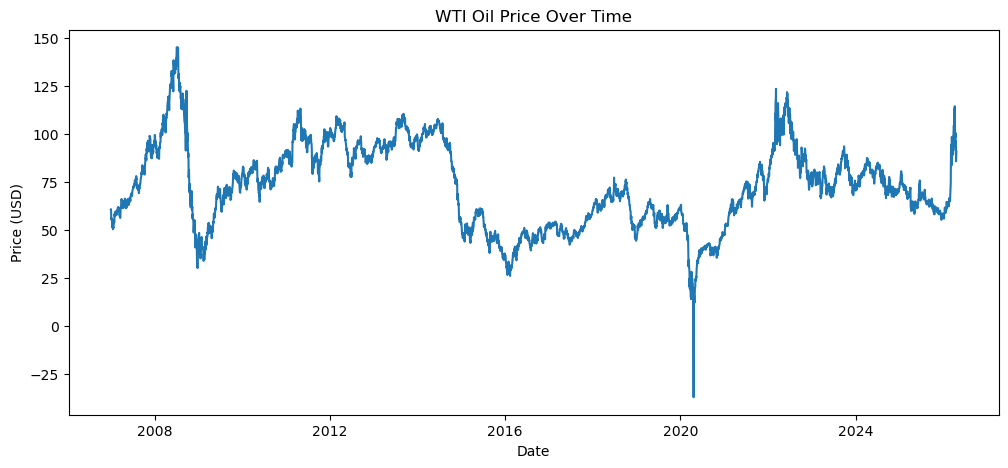

In [69]:
plt.figure(figsize=(12,5))
plt.plot(data["date"], data["price"])
plt.title("WTI Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

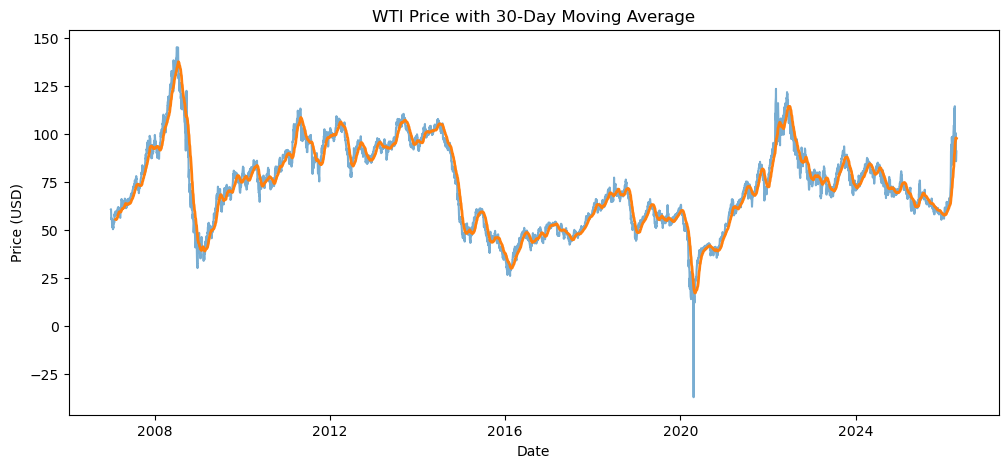

In [70]:
data["MA30"] = data["price"].rolling(30).mean()
plt.figure(figsize=(12,5))
plt.plot(data["date"], data["price"], alpha=0.6)
plt.plot(data["date"], data["MA30"], linewidth=2)
plt.title("WTI Price with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.savefig("figures/wti_moving_average.png")
plt.show()

In [71]:
#Only the first 29 values in our new column should be NaN. The right data is being loaded and processed.
data["MA30"].isna().sum()

np.int64(29)

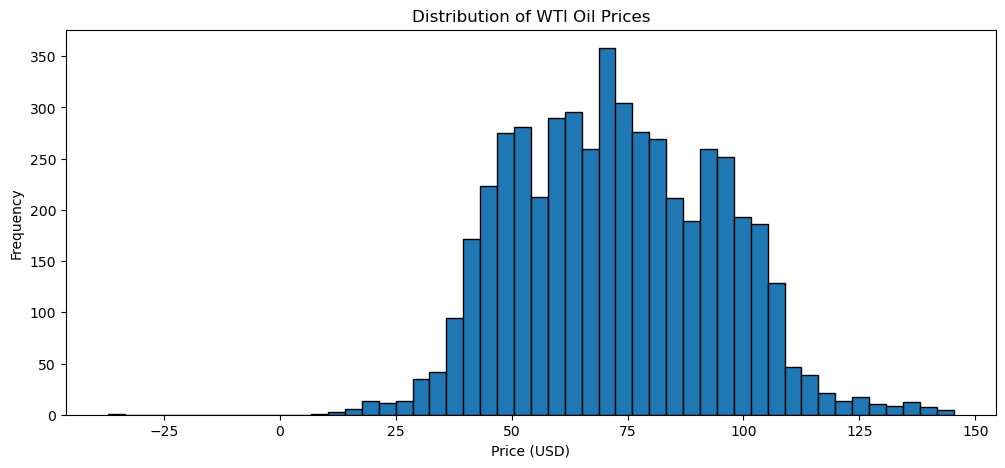

In [83]:
plt.figure(figsize=(12,5))
plt.hist(data['price'], bins=50, edgecolor="black")
plt.title("Distribution of WTI Oil Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.savefig("figures/wti_price_distribution.png")
plt.show()

In [73]:
#It is also very valuable to see the daily change in oil prices
data["returns"] = data["price"].pct_change()


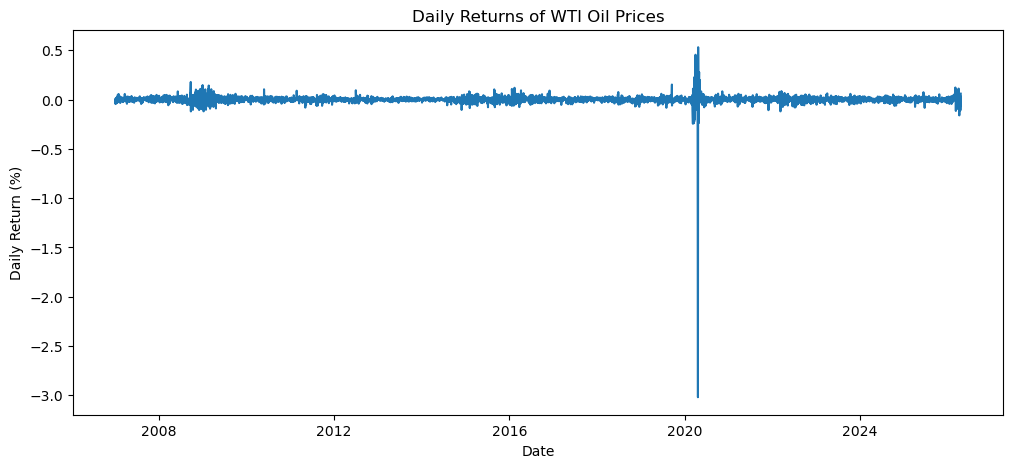

In [82]:
plt.figure(figsize=(12,5))
plt.plot(data["date"], data["returns"])

plt.title("Daily Returns of WTI Oil Prices")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.savefig("figures/wti_daily_returns.png")
plt.show()


In [75]:
data["year"] = data["date"].dt.year
yearly_avg = data.groupby("year")["price"].mean()


yearly_avg.head()

year
2007   72.30
2008   99.55
2009   61.81
2010   79.46
2011   94.91
Name: price, dtype: float64

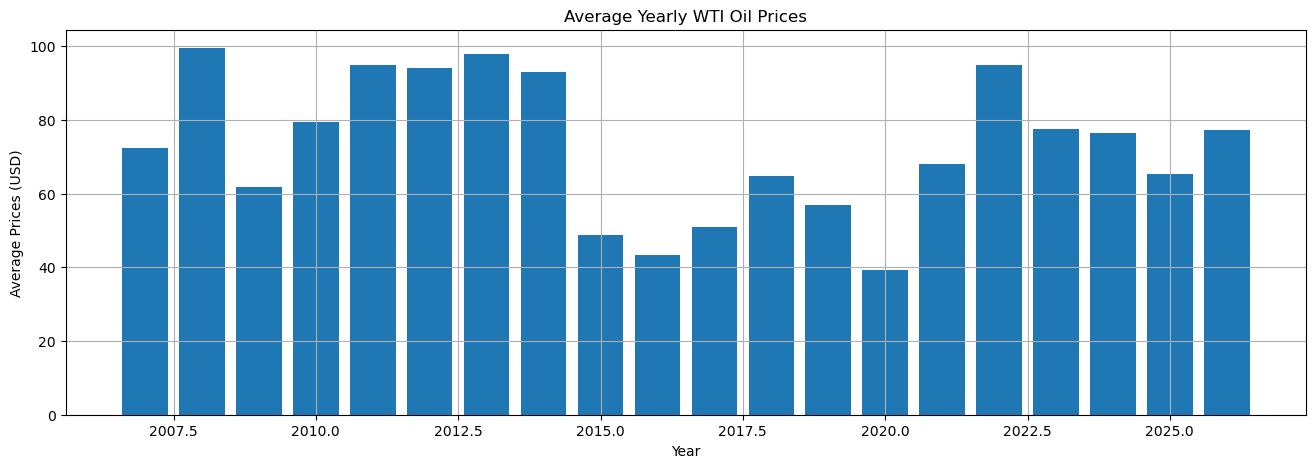

In [81]:
plt.figure(figsize=(16, 5))
plt.bar(yearly_avg.index, yearly_avg.values)

plt.title("Average Yearly WTI Oil Prices")
plt.xlabel("Year")
plt.ylabel("Average Prices (USD)")
plt.grid(True)
plt.savefig("figures/yearly_wti_avg.png")
plt.show()

## Data Processing for Alberta data

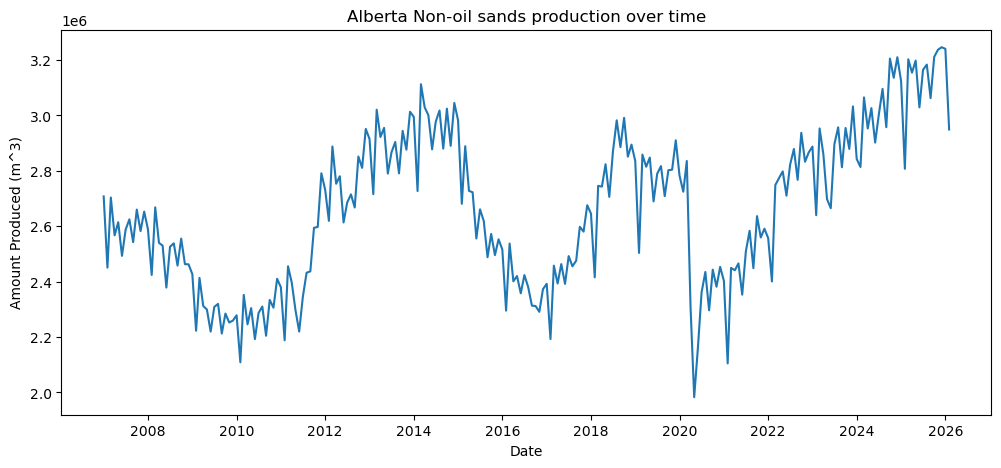

In [77]:
plt.figure(figsize=(12,5))
plt.plot(data_alb["date"], data_alb["Conventional Oil"])
plt.title("Alberta Non-oil sands production over time")
plt.xlabel("Date")
plt.ylabel("Amount Produced (m^3)")
plt.show()

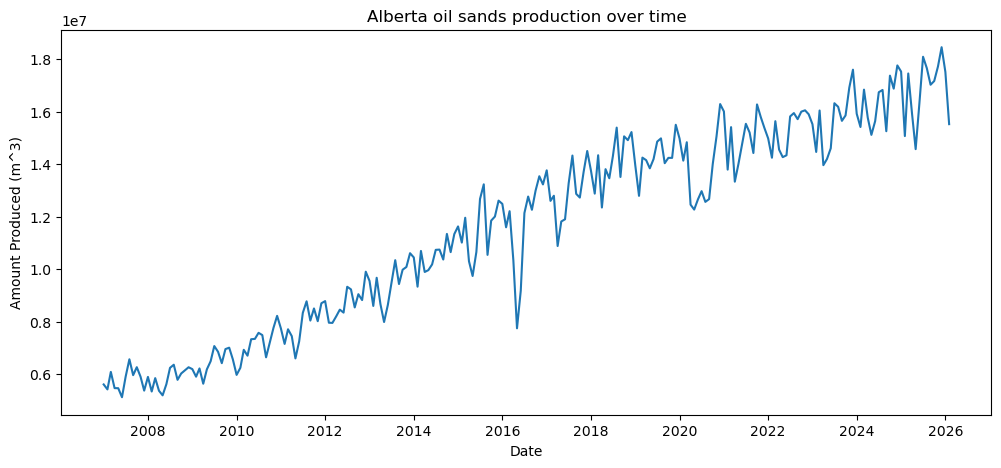

In [78]:
plt.figure(figsize=(12,5))
plt.plot(data_alb["date"], data_alb["Non-Conventional Oil"])
plt.title("Alberta oil sands production over time")
plt.xlabel("Date")
plt.ylabel("Amount Produced (m^3)")
plt.show()